In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("C:/Users/S.YUVADEEP/Downloads/load_forecasting_dataset_corrected.csv")

In [5]:
df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325


In [6]:
df.tail()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
189883,5/31/2025 22:45,27.433177,82.943227,1.564385,0.476854,214.276578,986.122824,487.823955,17.183842,5,22,5,Fall,0,1443.317681
189884,5/31/2025 23:00,32.085127,84.159944,1.389473,0.309841,308.798749,970.258350,515.405431,29.773656,5,23,5,Fall,0,1908.512650
189885,5/31/2025 23:15,27.620201,87.091108,2.722335,1.422315,282.487744,1007.429961,509.295868,24.883951,5,23,5,Fall,0,1462.020111
189886,5/31/2025 23:30,29.378415,75.743129,2.317605,9.383305,246.291089,1019.239724,536.514530,27.765615,5,23,5,Fall,0,1637.841485
189887,5/31/2025 23:45,27.737078,83.529497,0.914573,9.901955,299.088224,1020.425273,518.742211,15.496762,5,23,5,Fall,0,1473.707828


In [7]:
df.isnull()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189883,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
189884,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
189885,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
189886,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Timestamp                      0
Temperature (°C)               0
Humidity (%)                   0
Wind Speed (m/s)               0
Rainfall (mm)                  0
Solar Irradiance (W/m²)        0
GDP (LKR)                      0
Per Capita Energy Use (kWh)    0
Electricity Price (LKR/kWh)    0
Day of Week                    0
Hour of Day                    0
Month                          0
Season                         0
Public Event                   0
Load Demand (kW)               0
dtype: int64

In [9]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
189883    False
189884    False
189885    False
189886    False
189887    False
Length: 189888, dtype: bool

In [10]:
pd.to_datetime(df["Timestamp"])

0        2020-01-01 00:00:00
1        2020-01-01 00:15:00
2        2020-01-01 00:30:00
3        2020-01-01 00:45:00
4        2020-01-01 01:00:00
                 ...        
189883   2025-05-31 22:45:00
189884   2025-05-31 23:00:00
189885   2025-05-31 23:15:00
189886   2025-05-31 23:30:00
189887   2025-05-31 23:45:00
Name: Timestamp, Length: 189888, dtype: datetime64[us]

In [11]:
df["Date"]=pd.to_datetime(df["Timestamp"],errors="coerce")

In [12]:
df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Date
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831,2020-01-01 00:00:00
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140,2020-01-01 00:15:00
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708,2020-01-01 00:30:00
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971,2020-01-01 00:45:00
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325,2020-01-01 01:00:00


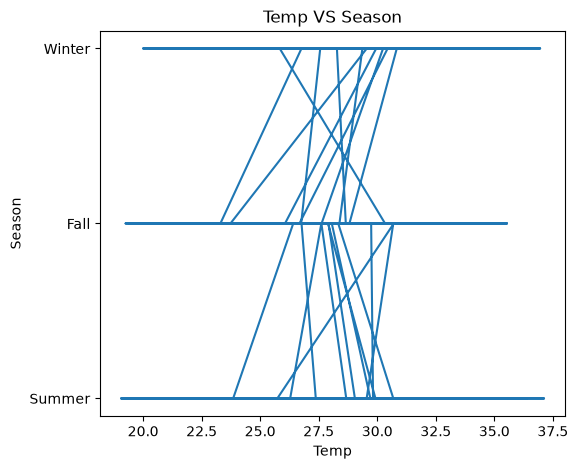

In [21]:
plt.figure(figsize=(6,5))
plt.plot(df['Temperature (°C)'],df['Season'])
plt.xlabel("Temp")
plt.ylabel("Season")
plt.title("Temp VS Season")

plt.show()

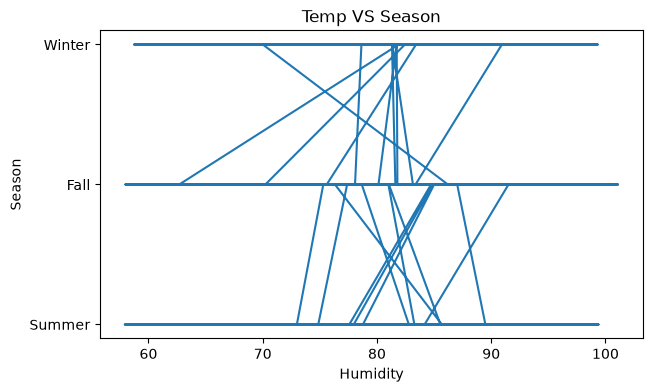

In [28]:
plt.figure(figsize=(7,4))
plt.plot(df['Humidity (%)'],df['Season'])
plt.xlabel("Humidity")
plt.ylabel("Season")
plt.title("Temp VS Season")

plt.show()

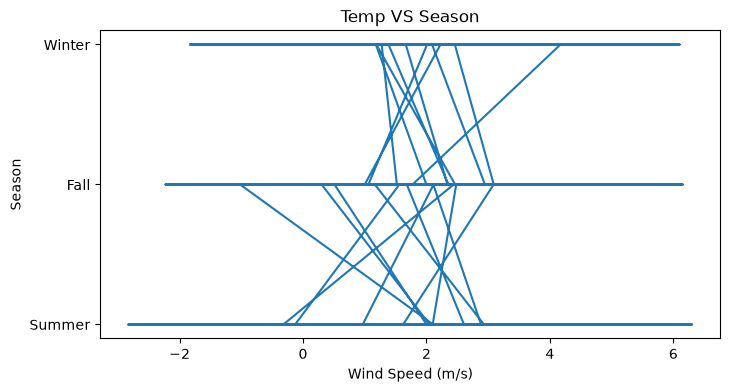

In [29]:
plt.figure(figsize=(8,4))
plt.plot(df['Wind Speed (m/s)'],df['Season'])
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Season")
plt.title("Temp VS Season")

plt.show()

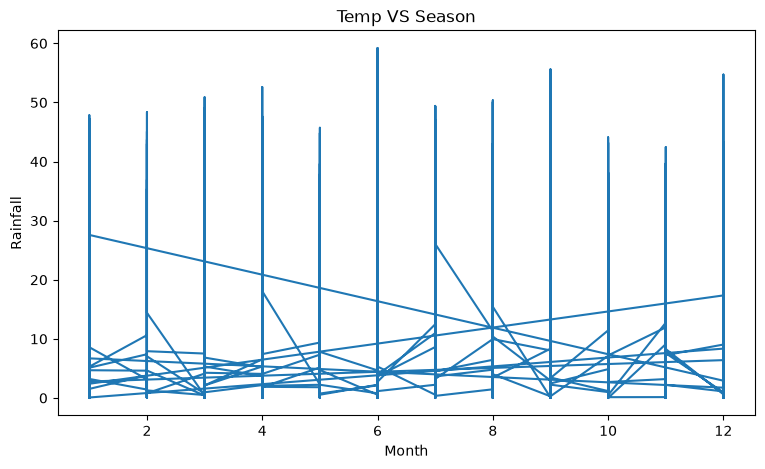

In [30]:
plt.figure(figsize=(9,5))
plt.plot(df['Month'],df['Rainfall (mm)'])
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.title("Temp VS Season")

plt.show()

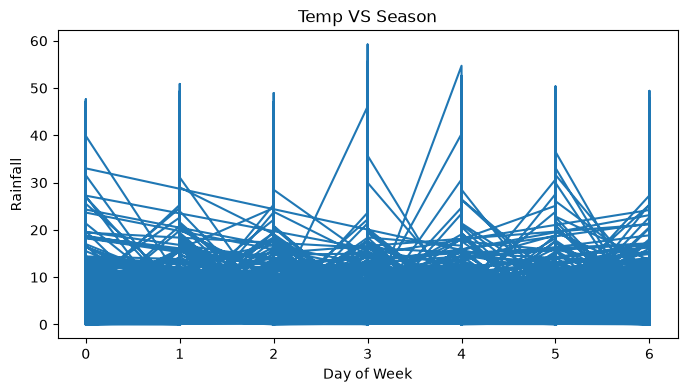

In [31]:
plt.figure(figsize=(8,4))
plt.plot(df['Day of Week'],df['Rainfall (mm)'])
plt.xlabel("Day of Week")
plt.ylabel("Rainfall")
plt.title("Temp VS Season")

plt.show()

In [26]:
df["yuvi"]=df["Month"].rolling(window=5).mean()

In [33]:
df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Date,yuvi
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831,2020-01-01 00:00:00,NaN
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140,2020-01-01 00:15:00,NaN
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708,2020-01-01 00:30:00,NaN
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971,2020-01-01 00:45:00,NaN
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325,2020-01-01 01:00:00,1.0


In [34]:
df.tail()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Date,yuvi
189883,5/31/2025 22:45,27.433177,82.943227,1.564385,0.476854,214.276578,986.122824,487.823955,17.183842,5,22,5,Fall,0,1443.317681,2025-05-31 22:45:00,5.0
189884,5/31/2025 23:00,32.085127,84.159944,1.389473,0.309841,308.798749,970.258350,515.405431,29.773656,5,23,5,Fall,0,1908.512650,2025-05-31 23:00:00,5.0
189885,5/31/2025 23:15,27.620201,87.091108,2.722335,1.422315,282.487744,1007.429961,509.295868,24.883951,5,23,5,Fall,0,1462.020111,2025-05-31 23:15:00,5.0
189886,5/31/2025 23:30,29.378415,75.743129,2.317605,9.383305,246.291089,1019.239724,536.514530,27.765615,5,23,5,Fall,0,1637.841485,2025-05-31 23:30:00,5.0
189887,5/31/2025 23:45,27.737078,83.529497,0.914573,9.901955,299.088224,1020.425273,518.742211,15.496762,5,23,5,Fall,0,1473.707828,2025-05-31 23:45:00,5.0


In [39]:
value1 = df["Month"].iloc[1]
value2 = df["Month"].iloc[5]

if value2 > value1:
    print("Increasing Trend")
elif value2 > value1:
    print("Decreasing Trend")
else:
    print("Stable Trend")



Stable Trend
